# Tarea 8. Gracida Salgado Angel David

Reproduce los dos experimentos vistos en clase: el modelo base sin regularización y el modelo con Dropout y regularización L2. Usa todas las imágenes y entrena ambos modelos durante 200 épocas con un 20% de validación y registra las pérdidas de entrenamiento y validación. Te recomiendo activar la runtime con GPU en Colab.

Primero el modelo sin regularización

In [ ]:
from keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
#transformamos los datos de entrenamiento y prueba en un array de 28x28 (usamos todos)
X_train = X_train.reshape(X_train.shape[0], 28 * 28)
X_test = X_test.reshape(X_test.shape[0], 28 * 28)

In [ ]:
#Transformamos a tipo flotante los datos para poder ser escalados
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

In [ ]:
#usamos minmaxscaler para escalar todos los datos en valores entre 0 y 1, conserva la forma de la distribución original
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
#Usamos to_categorical para transformar los vectores de enteros en matrices binarias restringidas a 10 clases
#Esto servira para crossentropy
#Esta chido por que a cada una de las clases enteras las transforma en un vector de puros ceros y unos, donde el uno se pone en la posición numérica de la
#clase entera
#La desventaja es que aumenta la dimension
from tensorflow.keras.utils import to_categorical
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense #dense es el tipo de capa
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(784,))) #add añade capas de neuronas
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile( #esto es un balance antes de mandarlo a entrenamiento
optimizer='adam', #adam es un algoritmo para descargar pesos
loss='categorical_crossentropy', #esta funcion mide como se esta equivocando el modelo
metrics=['accuracy'] #la metrica que va a medir
)
model.summary()

#Parámetros= (neuronas de entrada)*(neuronas de salida)+sesgos, hay un sesgo por cada neurona en una capa

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_base = model.fit(
X_train, y_train_cat,
validation_split=0.2,
epochs=200,
batch_size=512,
verbose=1
)

Epoch 1/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.8271 - loss: 0.6343 - val_accuracy: 0.9299 - val_loss: 0.2542
Epoch 2/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9358 - loss: 0.2256 - val_accuracy: 0.9457 - val_loss: 0.1892
Epoch 3/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9520 - loss: 0.1648 - val_accuracy: 0.9578 - val_loss: 0.1488
Epoch 4/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9623 - loss: 0.1298 - val_accuracy: 0.9604 - val_loss: 0.1381
Epoch 5/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9693 - loss: 0.1054 - val_accuracy: 0.9655 - val_loss: 0.1180
Epoch 6/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9751 - loss: 0.0874 - val_accuracy: 0.9676 - val_loss: 0.1088
Epoch 7/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9787 - loss: 0.0756 - val_accuracy: 0.9697 - val_loss: 0.1070
Epoch 8/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9820 - loss: 0.0631 - val_accuracy: 0.9712 - 

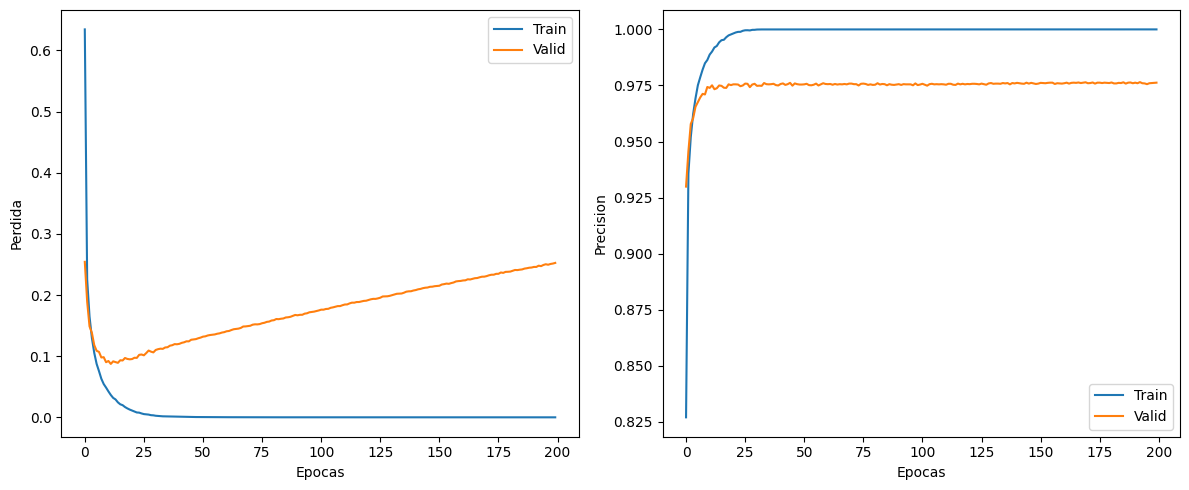

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_base.history['loss'], label='Train')
plt.plot(history_base.history['val_loss'], label='Valid')
plt.xlabel('Epocas')
plt.ylabel('Perdida')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_base.history['accuracy'], label='Train')
plt.plot(history_base.history['val_accuracy'], label='Valid')
plt.xlabel('Epocas')
plt.ylabel('Precision')
plt.legend()
plt.tight_layout()
plt.show()

Precision en test: 0.977
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.96      0.98      0.97      1010
           4       0.98      0.97      0.98       982
           5       0.98      0.96      0.97       892
           6       0.97      0.97      0.97       958
           7       0.98      0.98      0.98      1028
           8       0.97      0.97      0.97       974
           9       0.98      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



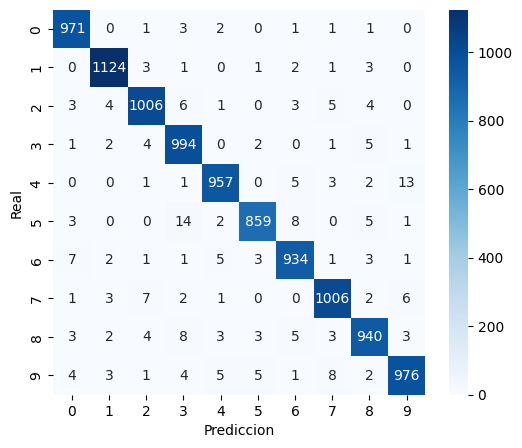

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Precision en test: {test_acc:.3f}")
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
print(classification_report(y_test, y_pred_classes))
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_classes),
annot=True, fmt='d', cmap='Blues')

plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.show()

Vemos que las curvas de perdida y accuracy evidencian un comportamiento de sobreajuste, ya que la curva de validación comienza a crecer cuando la de entrenamiento decrece, y las curvas de accuracy no se juntan totalmente en valores cercanos a 1. Por otra parte en la matriz de confusion, vemos que el modelo se equivoca mucho al clasificar números 5, ya que los confunde con números 3 (11 veces), y los números 9 los confunde con números 4 (10 veces).

Modelo con Dropout y regularización

Dropout y L2

In [ ]:
from tensorflow.keras.layers import Dropout
from tensorflow.keras.regularizers import l2


(X_train, y_train), (X_test, y_test) = mnist.load_data() #volvemos a cargar el conjunto de datos, robandonos el código del profesor

X_train = X_train.reshape(X_train.shape[0], 28 * 28).astype('float32') #volvemos a hacer el tratamiento de antes, para refrescar
X_test = X_test.reshape(X_test.shape[0], 28 * 28).astype('float32')

scaler = MinMaxScaler(feature_range=(0, 1))
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [ ]:
#Aplicamos el modelo dropout con 30% de neuronas y L2 con un parámetro de 0.001
model_reg = Sequential()
model_reg.add(Dense(128, activation='relu', input_shape=(784,), kernel_regularizer=l2(0.001)))

model_reg.add(Dropout(0.30))
model_reg.add(Dense(64, activation='relu',
kernel_regularizer=l2(0.001)))

model_reg.add(Dropout(0.30))
model_reg.add(Dense(10, activation='softmax'))
model_reg.compile(
optimizer='adam',
loss='categorical_crossentropy',
metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history_reg = model_reg.fit(
X_train, y_train_cat,
validation_split=0.2,
epochs=200,
batch_size=512,
verbose=1
)

Epoch 1/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.7182 - loss: 1.1301 - val_accuracy: 0.9168 - val_loss: 0.5065
Epoch 2/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8849 - loss: 0.5915 - val_accuracy: 0.9391 - val_loss: 0.4059
Epoch 3/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9121 - loss: 0.4870 - val_accuracy: 0.9469 - val_loss: 0.3555
Epoch 4/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9253 - loss: 0.4287 - val_accuracy: 0.9535 - val_loss: 0.3192
Epoch 5/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9332 - loss: 0.3859 - val_accuracy: 0.9587 - val_loss: 0.2927
Epoch 6/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9373 - loss: 0.3569 - val_accuracy: 0.9624 - val_loss: 0.2710
Epoch 7/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9429 - loss: 0.3304 - val_accuracy: 0.9639 - val_loss: 0.2537
Epoch 8/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9473 - loss: 0.3126 - val_accuracy: 0.9653 - 

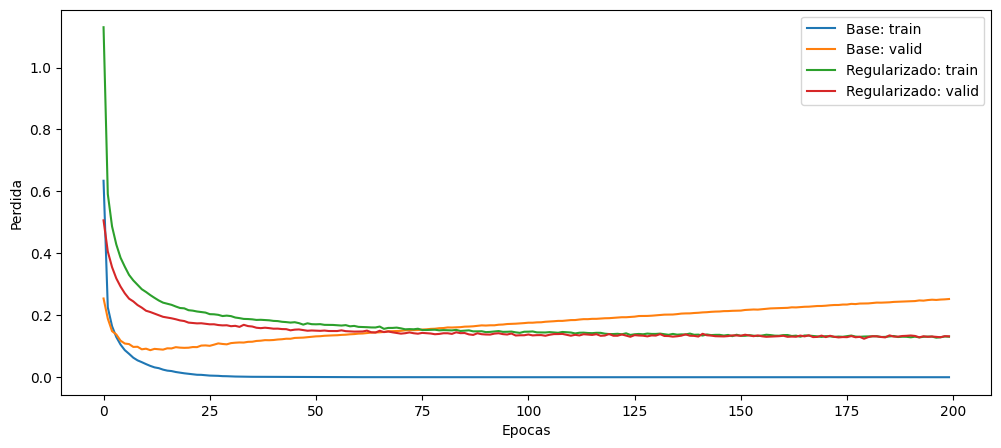

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(history_base.history['loss'], label='Base: train')
plt.plot(history_base.history['val_loss'], label='Base: valid')
plt.plot(history_reg.history['loss'], label='Regularizado: train')
plt.plot(history_reg.history['val_loss'], label='Regularizado: valid')
plt.xlabel('Epocas')
plt.ylabel('Perdida')
plt.legend()



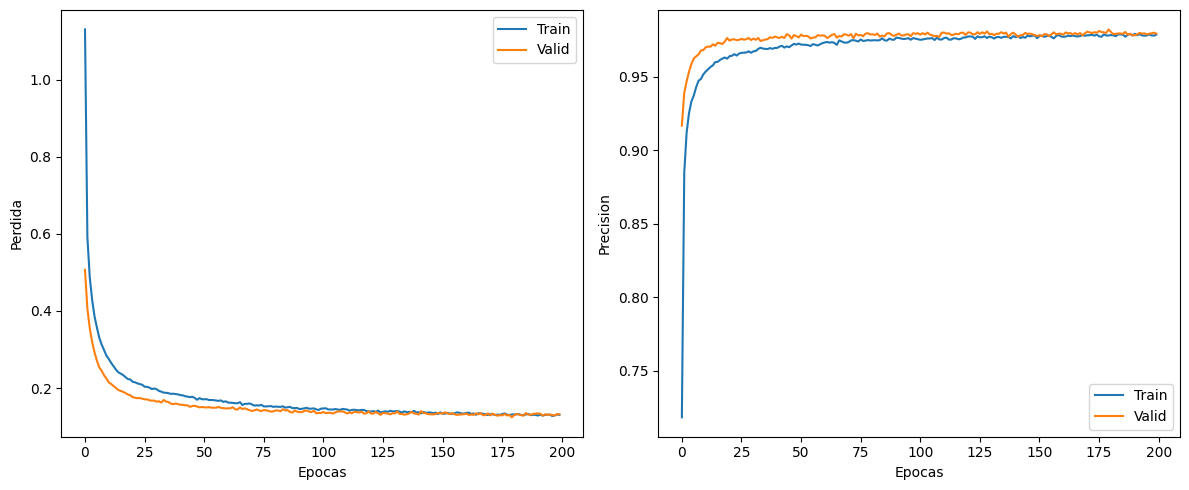

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_reg.history['loss'], label='Train')
plt.plot(history_reg.history['val_loss'], label='Valid')
plt.xlabel('Epocas')
plt.ylabel('Perdida')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_reg.history['accuracy'], label='Train')
plt.plot(history_reg.history['val_accuracy'], label='Valid')
plt.xlabel('Epocas')
plt.ylabel('Precision')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
base_loss, base_acc = model.evaluate(X_test, y_test_cat, verbose=0)
reg_loss, reg_acc = model_reg.evaluate(X_test, y_test_cat, verbose=0)
print(f"Base: {base_acc:.3f}")
print(f"Regularizado: {reg_acc:.3f}")

Base: 0.977
Regularizado: 0.979


Vemos que el overfitting fue reparado aplicando Dropout y L2, siendo que ahora ambas curvas tanto de perdida como de precisión tienden a cero y 1 en sus respectivos límites.

Hay diferencias en tus resultados respecto al experimento con 10,000 imágenes?
Haz la matriz de confusión y checa dónde se equivoca más el modelo, qué números confunde y si el modelo regularizado se equivoca menos o igual?

Sí hay diferencia con respecto al experimento de las 10 mil imágenes, dado que en este caso (el regularizado) las curvas de pérdida y precisión convergen en el límite de
grandes épocas a un mismo valor (0 para las pérdidas y 1 para el accuracy), por lo que no debe de existir overfiting. Por el contrario, en el caso de las 10 mil imágenes, las curvas de pérdida y validación no se juntan en el límite grandes épocas, si no que cruzan en algún punto y luego se separan. Por otra parte, el comportamiento del modelo base es similar en ambos casos (10 mil imágenes y con el total), puesto que no hay ninguna regulación, no obstante las precisiones en ambos modelos son muy similares de 0.93 y 0.937 (caso 10 mil imágenes), contrario al caso del total de imagenes donde las precisiones son de 0.978 y 0.981 lo que evidencia una mejora considerable con regulación.

Precision en test: 0.977
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.96      0.98      0.97      1010
           4       0.98      0.97      0.98       982
           5       0.98      0.96      0.97       892
           6       0.97      0.97      0.97       958
           7       0.98      0.98      0.98      1028
           8       0.97      0.97      0.97       974
           9       0.98      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



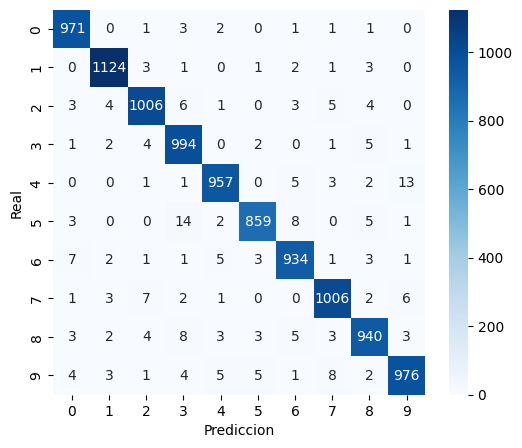

In [ ]:
#Modelo base
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Precision en test: {test_acc:.3f}")
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
print(classification_report(y_test, y_pred_classes))
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_classes),
annot=True, fmt='d', cmap='Blues')

plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.show()

Precision en test: 0.979
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.98      0.98      0.98      1010
           4       0.97      0.98      0.98       982
           5       0.98      0.98      0.98       892
           6       0.98      0.98      0.98       958
           7       0.98      0.97      0.97      1028
           8       0.98      0.97      0.98       974
           9       0.97      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



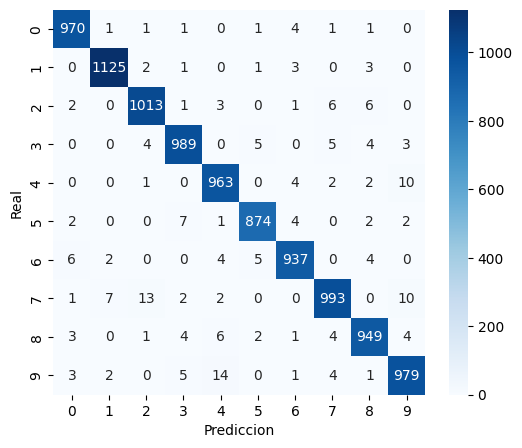

In [ ]:
#Modelo regularizado

test_loss, test_acc = model_reg.evaluate(X_test, y_test_cat, verbose=0)
print(f"Precision en test: {test_acc:.3f}")
y_pred = model_reg.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
print(classification_report(y_test, y_pred_classes))
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_classes),
annot=True, fmt='d', cmap='Blues')

plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.show()

A pesar de que la precisión mejora y el overfitting se reduce en el modelo regularizado, este tiene problemas para clasificar correctamente los numeros 9 (los confunde con 4, es donde mas falla), los 7 (los confunde con 2), y los 4 (los confunde con 9).
Aparentemente el modelo se equivoca igual que el modelo sin regularizar.

Analiza cómo varía la precisión final si cambias el valor de L2 o la tasa de
Dropout. Por ejemplo, prueba al menos dos valores distintos de λ y dos tasas distintas de Dropout.

Λ=0.0001 y 50 % dropout

In [ ]:
#Aplicamos el modelo dropout con 50% de neuronas y L2 con un parámetro de 0.0001
model_prue = Sequential()
model_prue.add(Dense(128, activation='relu', input_shape=(784,), kernel_regularizer=l2(0.0001)))

model_prue.add(Dropout(0.5))
model_prue.add(Dense(64, activation='relu',
kernel_regularizer=l2(0.0001)))

model_prue.add(Dropout(0.50))
model_prue.add(Dense(10, activation='softmax'))
model_prue.compile(
optimizer='adam',
loss='categorical_crossentropy',
metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history_prue = model_prue.fit(
X_train, y_train_cat,
validation_split=0.2,
epochs=200,
batch_size=512,
verbose=1
)

Epoch 1/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.5975 - loss: 1.2295 - val_accuracy: 0.8943 - val_loss: 0.4179
Epoch 2/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8309 - loss: 0.6004 - val_accuracy: 0.9236 - val_loss: 0.2931
Epoch 3/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8751 - loss: 0.4658 - val_accuracy: 0.9363 - val_loss: 0.2495
Epoch 4/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8937 - loss: 0.4071 - val_accuracy: 0.9463 - val_loss: 0.2210
Epoch 5/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9047 - loss: 0.3670 - val_accuracy: 0.9515 - val_loss: 0.2065
Epoch 6/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9139 - loss: 0.3379 - val_accuracy: 0.9560 - val_loss: 0.1916
Epoch 7/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9213 - loss: 0.3168 - val_accuracy: 0.9585 - val_loss: 0.1812
Epoch 8/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9258 - loss: 0.3006 - val_accuracy: 0.9600 - 

Precision en test: 0.977
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.97      0.98      0.97      1010
           4       0.97      0.98      0.98       982
           5       0.97      0.98      0.97       892
           6       0.98      0.98      0.98       958
           7       0.97      0.98      0.97      1028
           8       0.98      0.95      0.97       974
           9       0.97      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



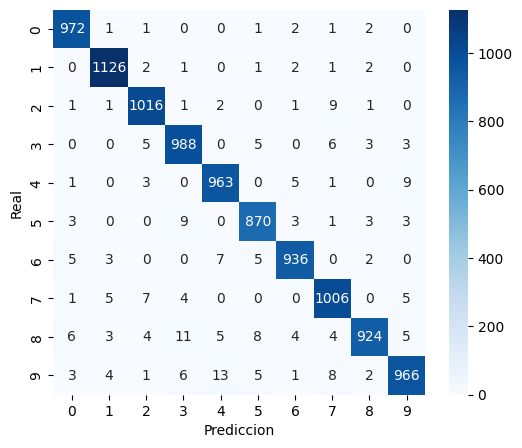

In [ ]:
test_loss, test_acc = model_prue.evaluate(X_test, y_test_cat, verbose=0)
print(f"Precision en test: {test_acc:.3f}")
y_pred = model_prue.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
print(classification_report(y_test, y_pred_classes))
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_classes),
annot=True, fmt='d', cmap='Blues')

plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.show()

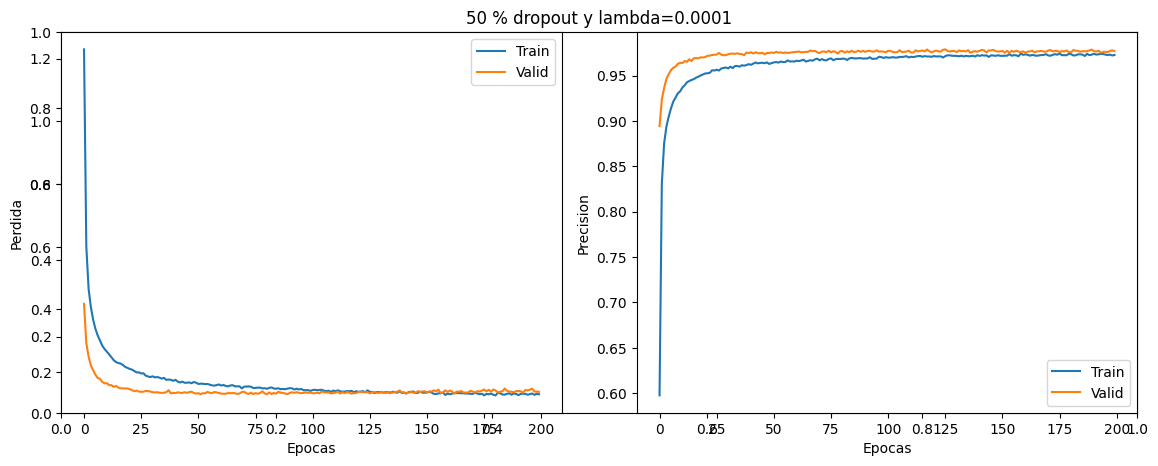

In [ ]:
plt.figure(figsize=(12, 5))
plt.title("50 % dropout y lambda=0.0001")
plt.subplot(1, 2, 1)
plt.plot(history_prue.history['loss'], label='Train')
plt.plot(history_prue.history['val_loss'], label='Valid')
plt.xlabel('Epocas')
plt.ylabel('Perdida')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_prue.history['accuracy'], label='Train')
plt.plot(history_prue.history['val_accuracy'], label='Valid')
plt.xlabel('Epocas')
plt.ylabel('Precision')
plt.legend()
plt.tight_layout()
plt.show()

Λ=0.01 y 50 % dropout

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.5770 - loss: 2.7908 - val_accuracy: 0.8934 - val_loss: 1.2084
Epoch 2/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8130 - loss: 1.2121 - val_accuracy: 0.9099 - val_loss: 0.7757
Epoch 3/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8470 - loss: 0.9220 - val_accuracy: 0.9197 - val_loss: 0.6414
Epoch 4/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8620 - loss: 0.8114 - val_accuracy: 0.9229 - val_loss: 0.5800
Epoch 5/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8710 - loss: 0.7568 - val_accuracy: 0.9267 - val_loss: 0.5468
Epoch 6/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8746 - loss: 0.7238 - val_accuracy: 0.9252 - val_loss: 0.5316
Epoch 7/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8790 - loss: 0.7018 - val_accuracy: 0.9322 - val_loss: 0.5077
Epoch 8/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8816 - loss: 0.6819 - val_accuracy: 0.9302 - 

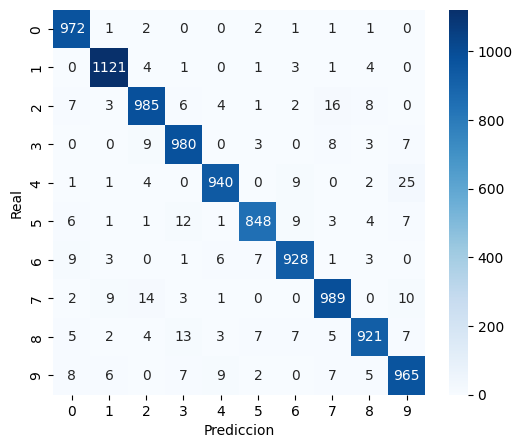

In [ ]:
#Aplicamos el modelo dropout con 50% de neuronas y L2 con un parámetro de 0.01
model_p2 = Sequential()
model_p2.add(Dense(128, activation='relu', input_shape=(784,), kernel_regularizer=l2(0.01)))

model_p2.add(Dropout(0.5))
model_p2.add(Dense(64, activation='relu',
kernel_regularizer=l2(0.01)))

model_p2.add(Dropout(0.50))
model_p2.add(Dense(10, activation='softmax'))
model_p2.compile(
optimizer='adam',
loss='categorical_crossentropy',
metrics=['accuracy']
)

history_p2 = model_p2.fit(
X_train, y_train_cat,
validation_split=0.2,
epochs=200,
batch_size=512,
verbose=1
)

test_loss, test_acc = model_p2.evaluate(X_test, y_test_cat, verbose=0)
print(f"Precision en test: {test_acc:.3f}")
y_pred = model_p2.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
print(classification_report(y_test, y_pred_classes))
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_classes),
annot=True, fmt='d', cmap='Blues')

plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.show()


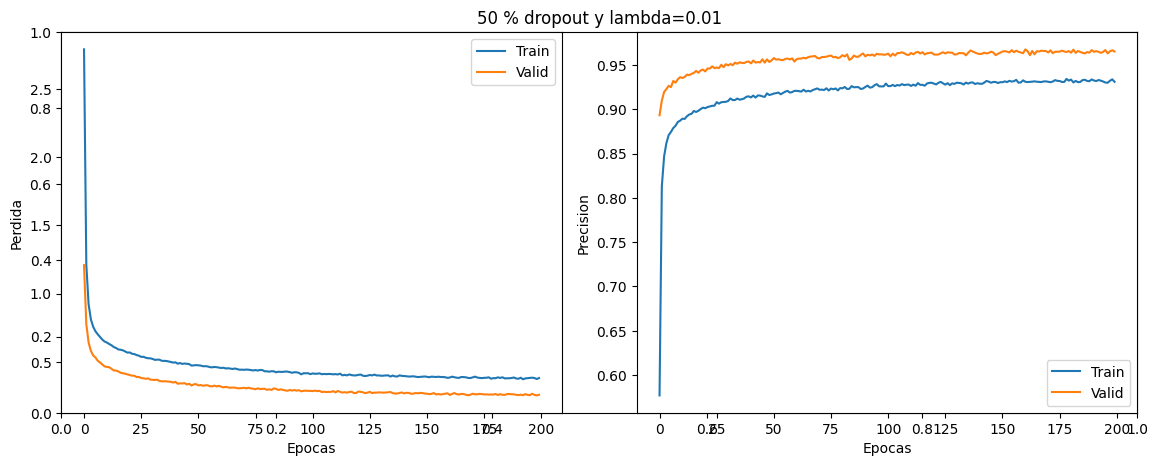

In [ ]:
plt.figure(figsize=(12, 5))
plt.title("50 % dropout y lambda=0.01")
plt.subplot(1, 2, 1)
plt.plot(history_p2.history['loss'], label='Train')
plt.plot(history_p2.history['val_loss'], label='Valid')
plt.xlabel('Epocas')
plt.ylabel('Perdida')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_p2.history['accuracy'], label='Train')
plt.plot(history_p2.history['val_accuracy'], label='Valid')
plt.xlabel('Epocas')
plt.ylabel('Precision')
plt.legend()
plt.tight_layout()
plt.show()

Λ=0.0001 y 10 % dropout

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.7923 - loss: 0.7373 - val_accuracy: 0.9269 - val_loss: 0.2899
Epoch 2/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9159 - loss: 0.3104 - val_accuracy: 0.9473 - val_loss: 0.2148
Epoch 3/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9387 - loss: 0.2399 - val_accuracy: 0.9563 - val_loss: 0.1803
Epoch 4/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9502 - loss: 0.2001 - val_accuracy: 0.9608 - val_loss: 0.1592
Epoch 5/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9576 - loss: 0.1757 - val_accuracy: 0.9645 - val_loss: 0.1484
Epoch 6/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9635 - loss: 0.1586 - val_accuracy: 0.9679 - val_loss: 0.1406
Epoch 7/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9682 - loss: 0.1407 - val_accuracy: 0.9703 - val_loss: 0.1320
Epoch 8/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9707 - loss: 0.1306 - val_accuracy: 0.9717 - 

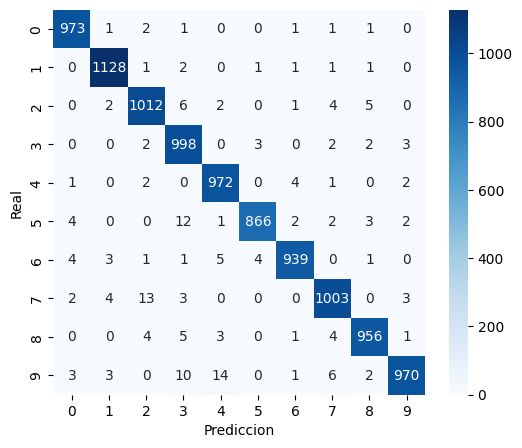

In [ ]:
#Aplicamos el modelo dropout con 10% de neuronas y L2 con un parámetro de 0.0001
model_p3 = Sequential()
model_p3.add(Dense(128, activation='relu', input_shape=(784,), kernel_regularizer=l2(0.0001)))

model_p3.add(Dropout(0.1))
model_p3.add(Dense(64, activation='relu',
kernel_regularizer=l2(0.0001)))

model_p3.add(Dropout(0.10))
model_p3.add(Dense(10, activation='softmax'))
model_p3.compile(
optimizer='adam',
loss='categorical_crossentropy',
metrics=['accuracy']
)

history_p3 = model_p3.fit(
X_train, y_train_cat,
validation_split=0.2,
epochs=200,
batch_size=512,
verbose=1
)

test_loss, test_acc = model_p3.evaluate(X_test, y_test_cat, verbose=0)
print(f"Precision en test: {test_acc:.3f}")
y_pred = model_p3.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
print(classification_report(y_test, y_pred_classes))
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_classes),
annot=True, fmt='d', cmap='Blues')

plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.show()


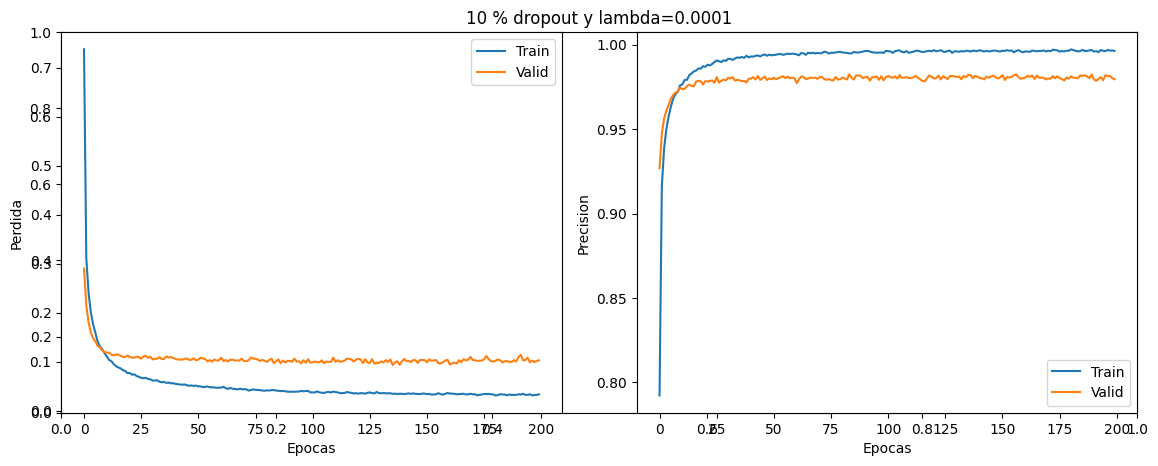

In [ ]:
plt.figure(figsize=(12, 5))
plt.title("10 % dropout y lambda=0.0001")
plt.subplot(1, 2, 1)
plt.plot(history_p3.history['loss'], label='Train')
plt.plot(history_p3.history['val_loss'], label='Valid')
plt.xlabel('Epocas')
plt.ylabel('Perdida')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_p3.history['accuracy'], label='Train')
plt.plot(history_p3.history['val_accuracy'], label='Valid')
plt.xlabel('Epocas')
plt.ylabel('Precision')
plt.legend()
plt.tight_layout()
plt.show()

Vemos que la precisión mas alta corresponde a 0.979 del modelo de  Λ=0.0001 y 50 % dropout, ya que no presenta sobreajuste y la precisión final es de 0.98. Por otro lado, el peor modelo es el de Λ=0.01 y 50 % dropout, ya que tiene una precisión final de 0.96 y un sobreajuste marcado en sus curvas de perdida.